배터리 이미지 EDA

In [1]:
import os

print(os.getcwd())

d:\02.study\part4_wj\Battery\Battery_Project\notebooks


In [2]:
import json
import glob

all_data = []

for file_name in glob.glob('../battery_label/*.json'):
    with open(file_name, 'r', encoding='utf-8') as f:
        data = json.load(f)
        all_data.append(data)

In [25]:
# 좌표 구조 시각적 검증
sample_data = all_data[54]
print("1. 전체 키 목록: ")
print(sample_data.keys())
print('-'*70)

1. 전체 키 목록: 
dict_keys(['data_info', 'swelling', 'defects', 'image_info'])
----------------------------------------------------------------------


In [26]:
if 'defects' in sample_data and sample_data['defects']:
    first_defect = sample_data['defects'][0]
    print("2. 결함 정보 상세: ")
    print(f"    - 종류(name): {first_defect.get('name')}")
    
    points = first_defect.get('points', [])
    print(f"    - points 데이터 길이 : {len(points)}개")
    print(f"    - points 데이터 앞 부분 추출 : {points[:4]}")
    print('-'*70)

2. 결함 정보 상세: 
    - 종류(name): Pollution
    - points 데이터 길이 : 62개
    - points 데이터 앞 부분 추출 : [949.0, 63.0, 984.0, 65.0]
----------------------------------------------------------------------


**데이터 형태 관찰 및 가설**

`points` 리스트의 길이사 짝수이며, 연속된 수치형 데이터로 구성 되어있습니다.

결함 영역을 나타내는 데이터의 특성상, `[x1, y1, x2, y2, ..]` 와 같이 x,y 좌표 쌍이 1차원 배열로 펼쳐져 나열된 형태일 가능성이 높다고 판단합니다.

이 가설을 검증하기 위해, 다음 단계에서 실제 원본 배터리의 이미지 위에 이 좌표들을 폴리곤(Polygon) 형태로 시각화하여 결함 위치와 일치하는지 교차 검증 하겠습니다.

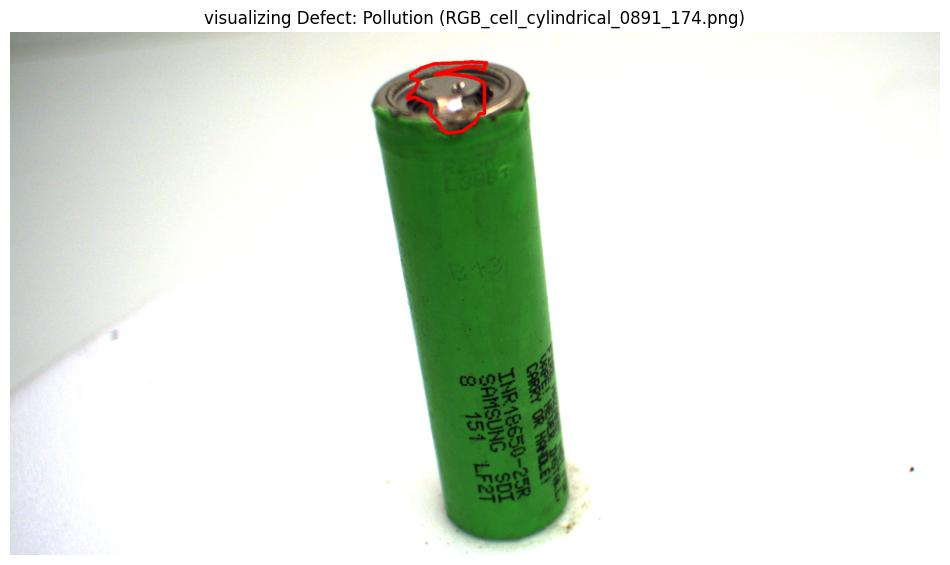

In [27]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. 이미지 경로 설정
image_dir = "../battery_image"
image_filename = sample_data.get('image_info', {}).get('file_name')
image_path = os.path.join(image_dir, image_filename)

# 2. 1차원 points 리스트를 (x,y) 쌍의 2차원 numpy 배열로 변환
# [x1, y1, x2, y2,..] -> [[x1, y1], [x2, y2], ...]
if len(points) >=4:
    # 정수형으로 변환 후 2열 구조로 재배열 (cv2.polylines 포멧)
    polygon_points = np.array(points, dtype=np.int32).reshape((-1, 2))
else:
    polygon_points = None

# 3. 이미지 로드 및 시각화
if os.path.exists(image_path) and polygon_points is not None:
    # 이미지 읽기
    img = cv2.imread(image_path)
    # OpenCV(BGR) -> Matplotlib(RGB) 변환
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # 이미지 위에 결함 영역(Polygon) 그리기
    cv2.polylines(img_rgb, [polygon_points], isClosed=True, color=(255,0,0), thickness=5)
    
    # 시각화
    plt.figure(figsize=(12,8))
    plt.imshow(img_rgb)
    plt.title(f"visualizing Defect: {first_defect.get('name')} ({image_filename})")
    plt.axis('off')
    plt.show()

In [28]:
from collections import Counter
defect_name = []

for data in all_data:
    # 1. data가 있는지
    # 2. 'defects' 가 있는지
    # 3. 그 값이 리스트인 경우 진행
    defects = data.get('defects')
    if isinstance(defects, list):
        for defect in defects:
            name = defect.get('name')
            if name:
                defect_name.append(name)
                
defect_counts = Counter(defect_name)
print(defect_counts)

Counter({'Pollution': 912, 'Damaged': 227})


In [29]:
total = sum(defect_counts.values())
for name, count in defect_counts.items():
    percentage = (count/total) * 100
    print(f"{name}: {count}개 ({percentage:.2f}%)")

Pollution: 912개 (80.07%)
Damaged: 227개 (19.93%)


전체 결함 중 `Pollution` 이 80%를 차지하고 `Damaged` 는 약 20% 정도 입니다.

데이터 불균형으로 인해 `Pollution` 만 잘 찾을 수 있고 `Damaged` 는 놓칠 가능성이 있습니다.

In [43]:
# 결함 이미지 확인

import cv2
import matplotlib.pyplot as plt
import random
random.seed(42)

# 이미지 폴더 경로 설정
IMAGE_DIR = '../battery_image'

def visualize_samples(all_data, target_defect, num_samples=3):
    # 1. 특정 경함이 포함된 데이터만 필터링
    samples = []
    for data in all_data:
        defects = data.get('defects')
        if defects and any(d.get('name') == target_defect for d in defects):
            samples.append(data)
            
    # 2. 무작위 진행
    if len(samples) > num_samples:
        selected_samples = random.sample(samples, num_samples)
    else:
        selected_samples = samples

    # 3. 시각화 설정
    plt.figure(figsize=(15,5))
    plt.suptitle(f"Defect Type: {target_defect}", fontsize=16)
    
    for i , data in enumerate(selected_samples):
        # JSON 정보에서 이미지 파일명 가져오기 (image_info 또는 파일명 매칭)
        img_name = data['image_info']['file_name']
        img_path = os.path.join(IMAGE_DIR, img_name)
        
        # 이미지 읽기
        img = cv2.imread(img_path)
        if img is None:
            continue
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        
        # 결함 위치 표시
        for defect in data.get('defects', []):
            if defect.get('name') == target_defect:
                points = defect.get('points', [])
                if len(points) >= 4: # 최소 2쌍 이상의 좌표 필요
                    poly_pts = np.array(points, dtype=np.int32).reshape((-1,2))
                    cv2.polylines(img, [poly_pts], isClosed=True, color=(255,0,0), thickness=8)
                    cv2.putText(img, target_defect, (poly_pts[0][0], poly_pts[0][1]-20),
                                cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255,0,0), 4)
                   
        # 출력
        plt.subplot(1, num_samples, i+1)
        plt.imshow(img)
        plt.title(f"File: {img_name}")
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()

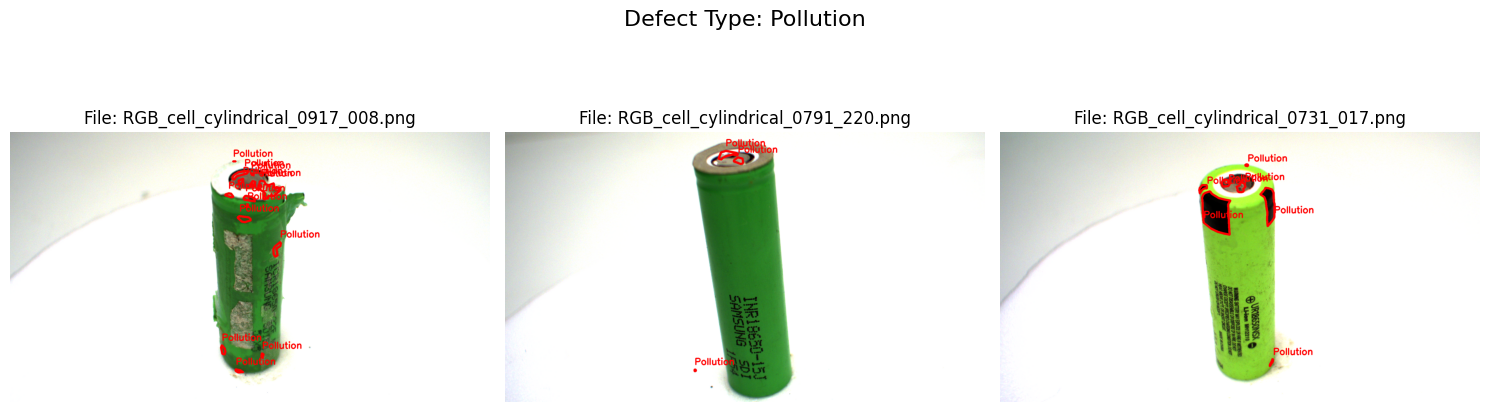

In [44]:
visualize_samples(all_data, 'Pollution', num_samples=3)

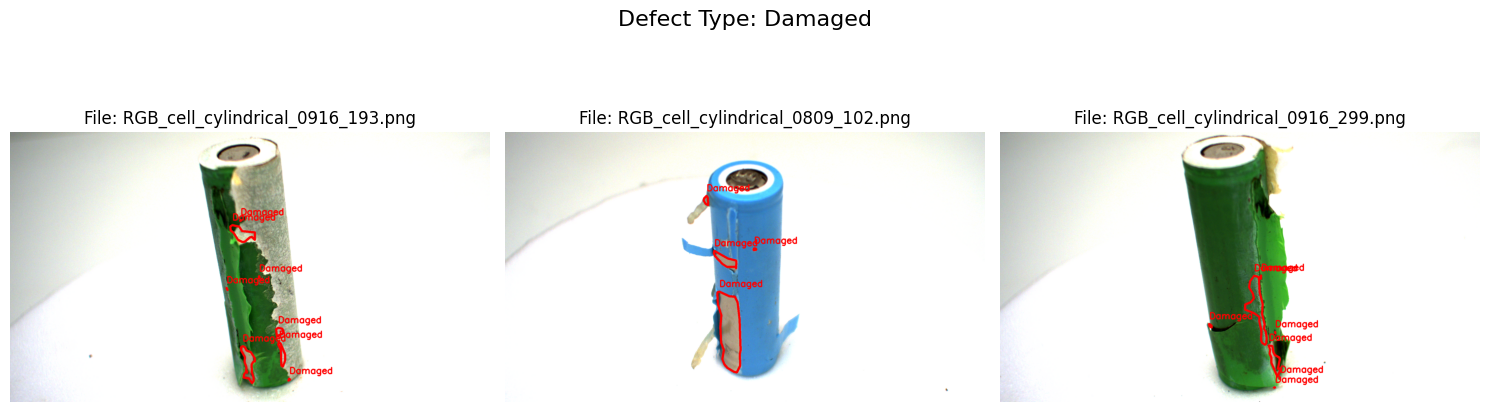

In [47]:
visualize_samples(all_data, 'Damaged', num_samples=3)

 ---
  ❓ 질문 1: "데이터 증강을 해야 할까요?"

  답: 증강은 하되, 그것만으론 부족합니다.

  증강은 유효 하지만, 80:20 정도 불균형은 사실 양호한 축입니다 (1:4). 머신비전 현장 결함 데이터셋은
   1:100 ~ 1:1000도 흔합니다. 그래서 증강만으로 Damaged를 충분히 학습 가능합니다.

  증강 전략 (D6/D11에서 적용):
  1. 클래스별 차등 증강: Damaged 포함 이미지에 더 강한 증강(Flip + Rotate + ElasticTransform
  조합)을 적용해 가짜로 양을 부풀림
  2. WeightedRandomSampler: PyTorch DataLoader에서 Damaged 이미지를 샘플링 확률 4배로 올림 (227×4
  ≈ 912)

  ⚠️  하지만 증강만의 한계: Damaged의 시각적 다양성 자체가 부족하면 증강은 같은 패턴을 반복 학습시킬
   뿐입니다. 그래서 다음 둘이 더 중요합니다.

  ---
  ❓ 질문 2: "품질 관리 우선순위를 어떻게 정해야 할까요?"

  답: 현장 우선순위 ≠ 모델 학습 균형 — 둘은 다른 축입니다.

  이게 본인의 2차전지 비전검사 경력 × AI 엔지니어의 차별점이 드러나는 지점입니다. README의 "결함
  우선순위" 섹션으로 적으면 채용 담당자에게 강력 어필 포인트가 됩니다.

  ┌───────────────┬──────────────────────────────────┬─────────────────────────────────────┐
  │      축       │         Pollution (이물)         │           Damaged (손상)            │
  ├───────────────┼──────────────────────────────────┼─────────────────────────────────────┤
  │ 빈도          │ 80%                              │ 20%                                 │
  ├───────────────┼──────────────────────────────────┼─────────────────────────────────────┤
  │ 현장 심각도   │ 보통 — 청소·필터링으로 대응      │ 높음 — 셀 자체 폐기, 발화·누액 위험 │
  ├───────────────┼──────────────────────────────────┼─────────────────────────────────────┤
  │ 검출 우선순위 │ 낮음 (False Negative 허용 폭 큼) │ 높음 (Recall 우선)                  │
  ├───────────────┼──────────────────────────────────┼─────────────────────────────────────┤
  │ 평가 메트릭   │ Precision-Recall 균형            │ Recall ≥ 0.95 목표                  │
  └───────────────┴──────────────────────────────────┴─────────────────────────────────────┘

  결론적 권장:
  - Damaged는 놓치면 안 되는 결함 (Critical Defect) 으로 정의 → 학습 시 class_weights = [1.0, 1.0,
  4.0] (background, Pollution, Damaged) 또는 Focal Loss 적용
  - 평가 시 Damaged의 Recall을 핵심 KPI로 명시 — mIoU 평균값 뒤에 "특히 Damaged Recall = X" 따로
  표기
  - 룰 기반(Matrox)과 앙상블 검토: DL이 놓친 Damaged를 룰이 잡고, 둘 중 하나라도 검출하면 알람
  (Recall 우선 정책)

  이 분석을 docs/data_card.md의 "결함 심각도 분석" 섹션과 README "비교 분석" 섹션 양쪽에 적으면 →
  면접 시 "데이터 분포만 본 게 아니라 현장 risk를 같이 봤구나"라는 인상.

  ---
  ❓ 질문 3: "swelling.swelling 값을 분포해야 할까요?"

  답: 반드시. 지금 D1-5 셀 C가 빠져있습니다.

  가이드 D1-5 체크리스트 중 셀 C/D/E/F가 아직 미작성 상태입니다. 셀 B(결함 종류)만 했고,
  swelling/is_normal/면적/개수 분포는 이번에 같이 해야 클래스 체계 결정 근거가 완성됩니다.

  특히 swelling 분포가 중요한 이유:
  - 만약 swelling.swelling=true인 샘플이 0개면 → "부풀음" 클래스는 학습 불가 → 2-class 확정
  - 만약 소수라도 존재하면 → Damaged와 어떻게 다른지 비교 검토 필요 (Damaged ⊃ swelling일 가능성)
  - battery_outline의 폴리곤은 swelling 값과 무관하게 항상 존재하는지도 같이 검증


**스웰링(Swelling) 유무 확인**

> 배터리 결함 중 하나인 '스웰링' 현상은 내부 가스 발생으로 인해 외형이 변형되는 심각한 불량입니다. 해당 데이터셋에서는 모든 이미지에 대해 스웰링 여부를 True/False로 제공하고 있으며, 대부분의 데이터가 False인 불균형 데이터인지 혹은 학습에 충분한 불량 사례가 있는지 확인이 필요합니다.

In [54]:
# swelling.swelling 분포
swelling_flags = []
for data in all_data:
    sw = data.get('swelling', {})
    swelling_flags.append(sw.get('swelling'))

from collections import Counter
print(Counter(swelling_flags))

Counter({False: 249})


**데이터셋 정상/불량 비율 확인**
>`is_normal` 플래그는 해당 이미지에 결함이 하나라도 존재하는지 여부를 나타내는 최상위 라벨입니다. 이는 모델이 '정상/불량'을 분류(Classification)하는 기준이 되며, 현재 데이터셋에서 정상 이미지와 결함 이미지가 어떤 비율로 구성되어 있는지 파악하여 학습 전략(데이터 증강 등)을 수립합니다

Counter({True: 160, False: 89})


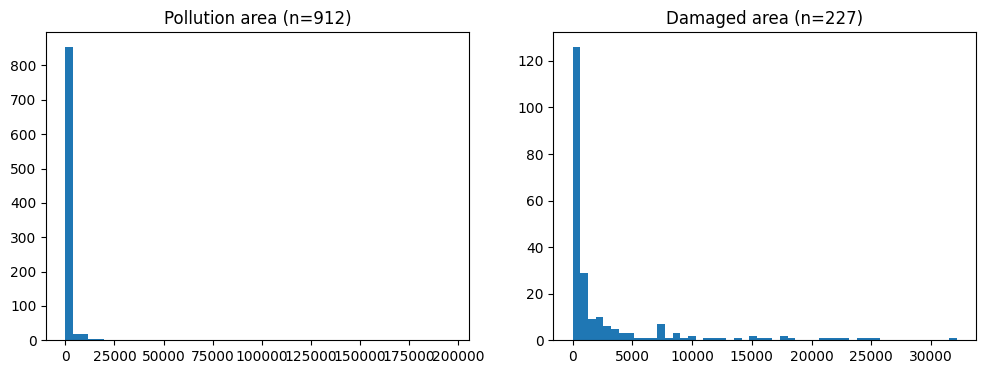

In [55]:
# image_info.is_normal 분포
normal_flags = [d.get('image_info', {}).get('is_normal') for d in all_data]
print(Counter(normal_flags))
# 정상 vs 비정상 비율

# 결함 면적 분포 (클래스별로 분리)
import numpy as np

areas_by_class = {'Pollution': [], 'Damaged': []}
for data in all_data:
    for defect in data.get('defects', []) or []:
        name = defect.get('name')
        pts = np.array(defect.get('points', [])).reshape(-1, 2).astype(np.float32)
        if len(pts) >= 3 and name in areas_by_class:
            # Shoelace formula 또는 cv2.contourArea
            area = 0.5 * abs(np.dot(pts[:,0], np.roll(pts[:,1], -1))
                            - np.dot(pts[:,1], np.roll(pts[:,0], -1)))
            areas_by_class[name].append(area)

# 히스토그램 비교
import matplotlib.pyplot as plt
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(areas_by_class['Pollution'], bins=50)
ax[0].set_title(f'Pollution area (n={len(areas_by_class["Pollution"])})')
ax[1].hist(areas_by_class['Damaged'], bins=50)
ax[1].set_title(f'Damaged area (n={len(areas_by_class["Damaged"])})')
plt.show()

**결함 복잡도 분석 (이미지당 결함 수)**
> 하나의 배터리 이미지에 여러 개의 결함이 동시에 존재할 수 있습니다. Pollution과 Damaged 각각의 이미지당 발생 개수를 분석함으로써, 결함이 밀집되어 나타나는 경향이 있는지 확인합니다. 만약 특정 이미지에 결함이 너무 많이 몰려 있다면, 이는 탐지 모델(Detection)의 난이도를 높이는 요인이 될 수 있습니다.

        Pollution     Damaged
count  249.000000  249.000000
mean     3.662651    0.911647
std      6.121638    2.454469
min      0.000000    0.000000
25%      0.000000    0.000000
50%      0.000000    0.000000
75%      6.000000    0.000000
max     25.000000   15.000000


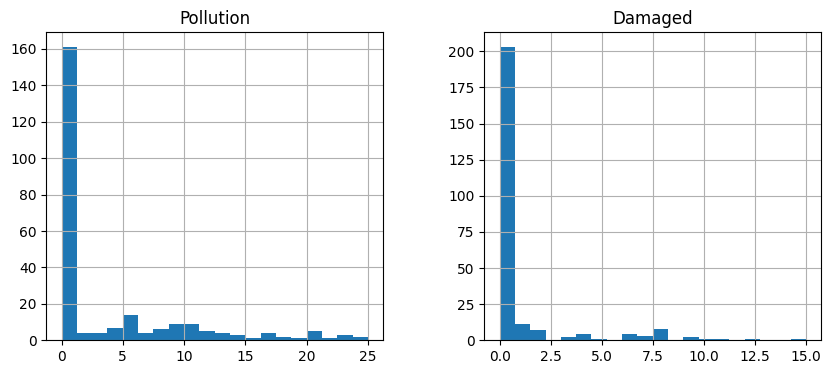

In [51]:
# 이미지당 결함 개수 분포 (Pollution/Damaged 별)
defect_counts_per_image = {'Pollution': [], 'Damaged': []}
for data in all_data:
    cnt = Counter(d.get('name') for d in data.get('defects', []) or [])
    defect_counts_per_image['Pollution'].append(cnt.get('Pollution', 0))
    defect_counts_per_image['Damaged'].append(cnt.get('Damaged', 0))
# 평균/중앙값/최대 → 표로 출력
import pandas as pd
df_cnt = pd.DataFrame(defect_counts_per_image)
print(df_cnt.describe())  # 평균/min/max/quartile
df_cnt.hist(bins=20, figsize=(10,4)); plt.show()

In [52]:
summary = {
      'total_images': len(all_data),
      'total_defects': total,
      'pollution_count': defect_counts['Pollution'],
      'damaged_count': defect_counts['Damaged'],
      'pollution_ratio': 0.8007,
      'damaged_ratio': 0.1993,
      'swelling_true': Counter(swelling_flags).get(True, 0),
      'is_normal_true': Counter(normal_flags).get(True, 0),
      'pollution_area_median': np.median(areas_by_class['Pollution']),
      'damaged_area_median': np.median(areas_by_class['Damaged']),
  }

pd.DataFrame([summary]).to_csv('eda_summary.csv', index=False)